# Step 6: Build Your First Machine Learning Model From Scratch

**Data Science Journey 2026 — @datasciencehorizon**

In Step 5, you explored the Iris dataset from every angle — bar plots, box plots, histograms, scatter plots, a pair plot, a correlation heatmap — and found that **Petal Length and Petal Width** were the two features that separated the three species almost perfectly.

Today, that insight finally pays off. We take it and build something that *predicts* — a real Machine Learning model, trained by you, evaluated by you, built from scratch, step by step, with nothing skipped.

A model has one job: look at **features** (inputs) and learn a rule that predicts a **label/target** (output). Today, our features are the four flower measurements. Our target is the species.

Full write-up: [datasciencehorizon.com](https://datasciencehorizon.com)


## 1. Setup — Picking Up Where Step 5 Left Off

Same Iris dataset. Same 150 flowers, same 3 species, same 4 features you already explored. No new dataset, no new algorithm at the same time — today you only need to learn what's new: the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

# Rebuilding the same iris_df from Step 5
iris = load_iris()
iris_df = pd.DataFrame(data=iris['data'], columns=iris['feature_names'])
iris_df['Species'] = pd.Series(iris['target']).apply(
    lambda x: 'setosa' if x == 0 else ('versicolor' if x == 1 else 'virginica'))
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. The Step Everyone Skips — Train/Test Split

Never test a model on the data you trained it on. If a model studies all 150 flowers and is then quizzed on those same 150, of course it does well — it memorised the answers. That tells you nothing about a flower it's never seen.

So we split into a **training set** (what the model learns from) and a **test set** (hidden until the very end, used only to grade it honestly). A common split is 80/20. Since our dataset is perfectly balanced (50 per species), we use `stratify` to preserve that balance in both sets.

In [2]:
feature_cols = ['sepal length (cm)', 'sepal width (cm)',
                'petal length (cm)', 'petal width (cm)']
X = iris_df[feature_cols]
y = iris_df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(120, 4) (30, 4)


**120 flowers to train on. 30 flowers the model will never see** until judgment day. This is the foundation of every honest Machine Learning workflow.

## 3. Choosing Your First Model — The Decision Tree

A **Decision Tree** asks a series of yes/no questions about your features, and each answer splits the data into smaller, purer groups, until it can confidently name the species.

This mirrors exactly what you did by eye in Step 5: *"if Petal Length is under 2, it's Setosa."* A Decision Tree asks exactly that kind of question — *"Is Petal Length less than 2.45?"* — and walks down a branch based on the answer.

Under the hood, at every split the tree tests many possible thresholds on every feature and picks the one that creates the purest possible groups (measured by **Gini impurity**). Because Petal Length and Petal Width were already the most separable features in our Step 5 EDA, they're about to become the most important questions in our tree.

## 4. Training the Model

In scikit-learn, every model follows the same three-step ritual: **create it, fit it, predict with it.**

In [3]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

A tree allowed to ask at most **3 questions deep**, so it stays simple and readable. `.fit()` is where learning actually happens — the tree looks at all 120 training flowers and works out the best questions to ask.

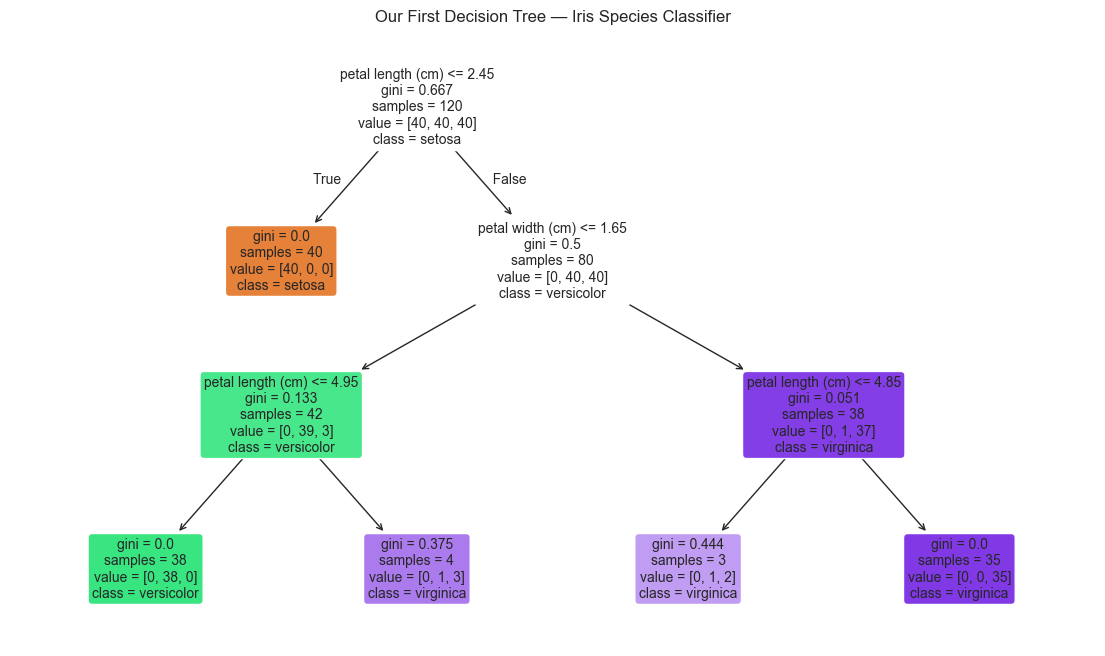

In [4]:
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=feature_cols, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Our First Decision Tree — Iris Species Classifier")
plt.show()

The very first question the tree chose, on its own: **"Is Petal Length ≤ 2.45?"** — almost word for word the rule you found by eye in the Step 5 box plot. The model discovered it from data, in a fraction of a second.

## 5. Making Predictions and Judging It Honestly

Now for the real test — the 30 flowers the model has never seen.

In [5]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 96.67%


On a clean, well-separated dataset like Iris, accuracy is usually well above 90%. But accuracy alone can hide mistakes — it tells you how often you were right, not where you went wrong. For that, we need a **confusion matrix**.

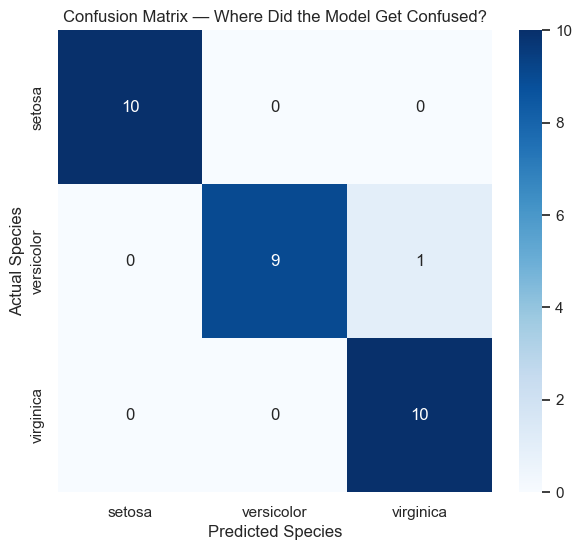

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix — Where Did the Model Get Confused?')
plt.show()

The diagonal is where the model got it right. Anything off the diagonal is a mistake — almost always **Versicolor mistaken for Virginica** or vice versa, matching the exact overlap you spotted in the Step 5 scatter plot. EDA predicted where the model would struggle, before we ever trained it.

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 6. Which Features Actually Mattered?

A Decision Tree can also tell us which features it actually relied on.

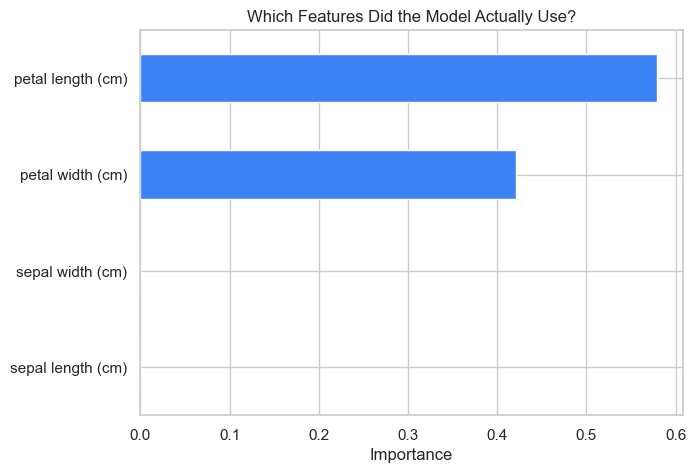

In [8]:
importances = pd.Series(clf.feature_importances_, index=feature_cols)
plt.figure(figsize=(7, 5))
importances.sort_values().plot(kind='barh', color='#3B82F6')
plt.title('Which Features Did the Model Actually Use?')
plt.xlabel('Importance')
plt.show()

**Petal Length and Petal Width dominate.** Sepal Length and Sepal Width barely matter. This confirms, mathematically, the exact same insight your correlation heatmap and pair plot gave you in Step 5.

## 7. The Mistake That Fools Every Beginner — Overfitting

Watch what happens if we let the tree ask unlimited questions instead of stopping at 3.

In [9]:
deep_clf = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_clf.fit(X_train, y_train)

print("Train accuracy:", deep_clf.score(X_train, y_train))
print("Test accuracy:", deep_clf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.9333333333333333


Training accuracy shoots up — often to **100%**. But test accuracy does not improve, and can even get worse. This is **overfitting** — the model didn't learn the pattern, it memorised the training flowers, including their noise. It looks perfect on data it has already seen, and shakier on anything new.

This is exactly why we hid the test set in the first place.

## Summary

We took the Iris dataset from Step 5, and for the first time split it into training and test sets — **120 to learn from, 30 to judge honestly**. We trained a Decision Tree and watched it independently rediscover the Petal Length rule we found by eye. We evaluated it with accuracy and a confusion matrix, and saw its mistakes line up exactly with the species overlap EDA had already warned us about. We checked feature importance, confirming Petal Length and Petal Width did almost all the work. And we saw first-hand why testing on unseen data is the only honest way to know if a model actually works.

That's your first real, working, evaluated Machine Learning model — built end to end, from scratch.

### Try It Yourself
- Change `max_depth` and see how the tree and confusion matrix change
- Try a different `test_size` in the train/test split
- Compare Gini impurity vs. entropy as the splitting criterion (`criterion='entropy'`)

---
More at [datasciencehorizon.com](https://datasciencehorizon.com) · Follow **@datasciencehorizon** · Next up: **Step 7 — Neural Networks and Deep Learning**
